# Total Variation Diminishing (TVD) Schemes and Limiters
In numerical solutions of hyperbolic conservation laws, higher–order schemes can produce non-physical oscillations near discontinuities.
These oscillations violate the monotonicity of the solution.
To prevent this, Total Variation Diminishing (TVD) schemes were introduced.
A scheme is called TVD if the total variation of the numerical solution does not increase with time.

## Linear Convection Equation
We consider the 1D linear convection equation
$
\frac{\partial u}{\partial t} + a\frac{\partial u}{\partial x} = 0
$
where
- $u(x,t)$ : transported quantity
- $a$ : constant advection speed
Initial condition:
$
u(x,0) =
\begin{cases}
1 & 0.4 \le x \le 0.6 \
0 & otherwise
\end{cases}
$


Boundary condition: Periodic

# Total Variation
The total variation (TV) of a discrete solution is

$
TV(u) = \sum_{i=1}^{N-1} |u_{i+1}-u_i|
$

A scheme is TVD if

$
TV(u^{n+1}) \le TV(u^n)
$

This ensures:
- No new oscillations
- Stable shock capturing
TVD schemes form the foundation of modern high-resolution shock-capturing methods.

# Need for Limiters
High-order schemes reconstruct the solution slope
$
\sigma_i = \frac{u_{i+1}-u_{i-1}}{2}
$
Near discontinuities this produces overshoots.
Limiters modify the slope to enforce TVD conditions.

# Two Forms of Limiters
Limiters are commonly implemented in two equivalent ways:
1. Slope limiter formulation
2. Flux limiter formulation

# 1. Slope Limiter Formulation
Define forward and backward slopes


$
\Delta u^+ = u_{i+1}-u_i
$

$
\Delta u^- = u_i-u_{i-1}
$


The limited slope becomes
$
\sigma_i = \text{Limiter}(\Delta u^-,\Delta u^+)
$


The reconstructed interface value is
$
u_{i+1/2}^L = u_i + \frac{1}{2}\sigma_i
$

## Minmod Slope Limiter
$
\text{minmod}(a,b) =
\begin{cases}
\text{sign}(a)\min(|a|,|b|) & ab>0 \
0 & ab \le 0
\end{cases}
$

# 2. Flux Limiter Formulation
Another popular formulation uses the ratio of slopes

$
r_i = \frac{\Delta u^-}{\Delta u^+}
$


The limited slope becomes


$
\sigma_i = \phi(r_i)\Delta u^+
$


where $\phi(r)$ is called the flux limiter function.

## Common Flux Limiters
### Minmod

$
\phi(r)=\max(0,\min(1,r))
$

### Superbee

$
\phi(r)=\max(0,\min(2r,1),\min(r,2))
$

### Venkatakrishnan Limiter
Used widely in compressible CFD codes.
$
\phi(r) =
\frac{r^2 + 2r}{r^2 + r + 2}
$
### VanLeer Limiter
$
\phi(r) =
\frac{r + |r|}{1 + |r|}
$

# Numerical Scheme
For positive velocity $a>0$

$$
u_i^{n+1} =
u_i^n
- \frac{a\Delta t}{\Delta x}
(u_{i+1/2}^L-u_{i-1/2}^L)
$$

The interface value is obtained using the limited slope.

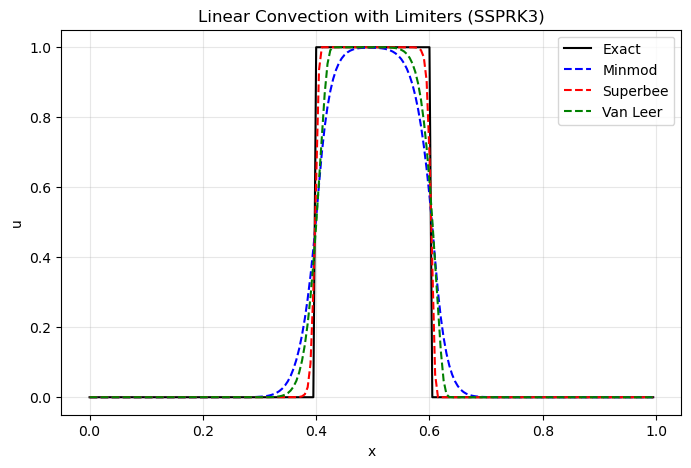

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Grid
# --------------------------------------------------

nx = 200
xmin = 0.0
xmax = 1.0

x = np.linspace(xmin, xmax, nx, endpoint=False)
dx = (xmax-xmin)/nx

a = 1.0

CFL = 0.5
dt = CFL*dx/abs(a)

t_final = 1.0
nt = int(t_final/dt)

# --------------------------------------------------
# Initial condition
# --------------------------------------------------

def initial_condition(x):
    u = np.zeros_like(x)
    u[(x>=0.4) & (x<=0.6)] = 1
    return u

# --------------------------------------------------
# Exact solution
# --------------------------------------------------

def exact_solution(x,t):
    x_shift = (x-a*t) % 1.0
    u = np.zeros_like(x)
    u[(x_shift>=0.4)&(x_shift<=0.6)] = 1
    return u


# --------------------------------------------------
# Limiter functions
# --------------------------------------------------

def minmod(r):
    return np.maximum(0, np.minimum(1, r))

def superbee(r):
    return np.maximum(0,
           np.maximum(np.minimum(2*r,1),
                      np.minimum(r,2)))

def van_leer(r):
    # Smooth limiter, standard for aerodynamic codes
    # Returns 0 for r < 0, and 2r/(1+r) for r > 0
    return (r + np.abs(r)) / (1.0 + np.abs(r))


# --------------------------------------------------
# Flux evaluation with limiter
# --------------------------------------------------

def compute_rhs(u, limiter):
    u_ext = np.concatenate(([u[-1]], u, [u[0]]))

    du_forward  = u_ext[2:] - u_ext[1:-1]
    du_backward = u_ext[1:-1] - u_ext[:-2]

    # Avoid division by zero
    r = du_backward/(du_forward + 1e-12)

    phi = limiter(r)

    slope = phi * du_forward

    uL = u_ext[1:-1] + 0.5*slope

    flux = a*uL

    flux_ext = np.concatenate(([flux[-1]], flux))

    rhs = -(flux_ext[1:] - flux_ext[:-1]) / dx

    return rhs


# --------------------------------------------------
# SSPRK3 Time Integration
# --------------------------------------------------

def solve(limiter):
    u = initial_condition(x)
    for n in range(nt):
        k1 = compute_rhs(u, limiter)
        u1 = u + dt*k1

        k2 = compute_rhs(u1, limiter)
        u2 = 0.75*u + 0.25*(u1 + dt*k2)

        k3 = compute_rhs(u2, limiter)
        u  = (1/3)*u + (2/3)*(u2 + dt*k3)
    return u


# --------------------------------------------------
# Run solutions
# --------------------------------------------------

u_minmod = solve(minmod)
u_superbee = solve(superbee)
u_vanleer = solve(van_leer)  # Replaced Venkat with Van Leer

u_exact = exact_solution(x,t_final)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(x,u_exact,'k',label="Exact")
plt.plot(x,u_minmod,'b--',label="Minmod")
plt.plot(x,u_superbee,'r--',label="Superbee")
plt.plot(x,u_vanleer,'g--',label="Van Leer")

plt.xlabel("x")
plt.ylabel("u")
plt.title("Linear Convection with Limiters (SSPRK3)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Observations
Minmod
- Very stable
- Diffusive
Superbee
- Very sharp shocks
- Can be aggressive
Venkatakrishnan
- Smooth limiter
- Widely used in compressible CFD solvers